# Preliminary: Analysis of the cosmology baseline $F$ problems

## Prelude

In [1]:
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sympy

import AnalysisUtils as au

In [3]:
feature = sympy.symbols("feature")
x1, x2 = sympy.symbols("x1:3")
x = sympy.abc.x
y = sympy.abc.y

## Load data

In [4]:
full_report = pd.read_csv("For-analysis/full-report.csv")

In [5]:
full_report.run_set.unique()

<StringArray>
['CHT-2026-07-20-1300', 'SRB-2026-07-20-1300', 'SRB-2026-07-25-1900']
Length: 3, dtype: str

In [6]:
full_report.sort_values(["run_set", "data_set", "mse"], inplace=True)
f_indices = full_report.data_set.apply(lambda x: x.startswith("F"))
fr2 = full_report.loc[f_indices].set_index(["run_set", "data_set", "sample_num"])

In [7]:
fr2["sympy"] = fr2.expr_original_syms.apply(au.parse_if_needed)
fr2["sympy_defuzz"] = fr2.expr_original_syms_defuzz.apply(au.parse_if_needed)

In [8]:
fr2

rating           mse  \
run_set             data_set sample_num                               
CHT-2026-07-20-1300 F1       31          5.819628e-11  4.747065e-21   
                             5           5.525000e-11  4.870763e-21   
                             10          5.262195e-11  8.582813e-21   
                             1           4.025000e-11  8.753471e-20   
                             4           5.556250e-11  1.208208e-19   
...                                               ...           ...   
SRB-2026-07-25-1900 F2       75          5.883752e-01  6.407012e-01   
                             147         6.155958e-01  6.612858e-01   
                             80          6.129109e-01  6.660691e-01   
                             110         6.161391e-01  6.921650e-01   
                             11          6.224724e-01  7.162130e-01   

                                         complexity  complexity_defuzz  \
run_set             data_set sample_num                                  
CHT-2026-07-20-1300 F1       31                  37                 35   
                             5                   32                 10   
                             10                  63                 40   
                             1                   19                 10   
                             4                   37                 27   
...                                             ...                ...   
SRB-2026-07-25-1900 F2       75                  42                 42   
                             147                145                142   
                             80                  70                 70   
                             110                 81                 81   
                             11                 109                 78   

                                                                                      expr  \
run_set             data_set sample_num                                                      
CHT-2026-07-20-1300 F1       31          -0.49999999999999356*x1**4*(-2*x1 - 0.025) - 1...   
                             5           1.0000000000000004*x1**5 - 1.9999999999999056*...   
                             10          -3.000000000002264*x1**3 + 0.5000000000000093*...   
                             1           0.9999999999999696*x1**5 - 1.9999999999964268*...   
                             4           4.716068217099984e-12*x1**4 + 1.00000000000007...   
...                                                                                    ...   
SRB-2026-07-25-1900 F2       75          1.25066610760437*cos(6.0683682578896728*x1) + ...   
                             147         -0.0040016955374804897*x1 + 22.090907101130128...   
                             80          0.0006947474381041614*x1**4 - 0.00458900970547...   
                             110         0.02101917326317429*x1**3 - 1.483982742417933*...   
                             11          0.013576511313888744*x1 + 0.013576511313888744...   

                                                                               expr_defuzz  \
run_set             data_set sample_num                                                      
CHT-2026-07-20-1300 F1       31          -0.499999999999994*x1**4*(-2*x1 - 0.025) - 1.9...   
                             5                                        x1**5 - 2*x1**3 + x1   
                             10          -3*x1**3 + 0.500000000000009*x1**2*(2*x1**3 + ...   
                             1                                        x1**5 - 2*x1**3 + x1   
                             4           x1**3*(x1**2 + x1) + x1**2 + x1 - 0.2500000000...   
...                                                                                    ...   
SRB-2026-07-25-1900 F2       75          1.25066610760437*cos(6.0683682578896728*x1) + ...   
                             147         -0.00400169553748049*x1 + 22.0909071011301*(co... 

In [9]:
srb3_key = "SRB-2026-07-20-1300"
cht4_key = "CHT-2026-07-20-1300"
srb3 = fr2.loc[srb3_key]
cht4 = fr2.loc[cht4_key]

In [10]:
(fr2.groupby(level=["run_set","data_set"]).size() == 32).all()

np.False_

These are the best ones overall

In [11]:
srb3_min_mse_ixs = srb3.groupby(level=["data_set"]).mse.idxmin()
cht4_min_mse_ixs = cht4.groupby(level=["data_set"]).mse.idxmin()

In [12]:
srb3.loc[srb3_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
F1,20,1.066684e-21,10,feature**5 - 2*feature**3 + feature
F2,26,4.495305e-02,143,0.00131010074784238*feature + (0.0091929776751...
F3,13,2.478819e+09,207,-2.07139577782893*feature**4 - 0.0003771696636...
F4,22,7.191662e-28,19,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...
F5,16,1.321405e-28,9,1.5*exp(x1) + 5*cos(x2)
F6,19,3.924793e-05,61,-0.000376061149024994*x2 - 0.00037606114902499...
F7,24,2.486402e-26,13,0.230000000000037 + (4.73333333333333*x1 + 4.7...
F8,4,1.592582e-26,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...


In [13]:
cht4.loc[cht4_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
F1,31,4.747065e-21,35,-0.499999999999994*feature**4*(-2*feature - 0....
F2,19,4.004955e-06,56,-410.74754998442*feature**2 - 15.7270870360052...
F3,20,5.741730e+09,88,-0.996168207705634*feature + 6.43879733729536e...
F4,25,1.033585e-27,19,2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...
F5,6,4.842086e-09,107,-2.59960384221269*x2**2 - 1.78238444793572*x2 ...
F6,6,4.505475e-04,84,1.33940841678884*x1**0.5 - 1.35804790284996*x1...
F7,19,2.349767e-26,13,0.230000000000016 + (4.73333333333333*x1 + 4.7...
F8,29,8.347441e-26,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...


To be consistent with all the other runs, I need to use `srb3` and `cht4` here.

In [14]:
srb_key = srb3_key
srb = srb3
srb_min_mse_ixs = srb3_min_mse_ixs
cht_key = cht4_key
cht = cht4
cht_min_mse_ixs = cht4_min_mse_ixs

## Polynomials

Generally, the polynomial problems are easy.

In [15]:
data_sets_polynomial = ["F1", "F4"]

The best ones are exactly correct.

In [16]:
srb.loc[srb_min_mse_ixs].loc[data_sets_polynomial, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
F1,20,1.066684e-21,10,feature**5 - 2*feature**3 + feature
F4,22,7.191662e-28,19,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...


In [17]:
au.count_by_threshold(srb.loc[data_sets_polynomial])

data_set
F1    13
F4    30
Name: mse, dtype: int64

With some generous defuzzing, SRB gets all of the $F_1$'s exactly.

In [18]:
(srb.loc["F1"]
    .sympy
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e).evalf(),
                                   tolerance=1e-6)))

sample_num
20                  feature**5 - 2*feature**3 + feature
21                  feature**5 - 2*feature**3 + feature
5                   feature**5 - 2*feature**3 + feature
22                  feature**5 - 2*feature**3 + feature
12                  feature**5 - 2*feature**3 + feature
4                   feature**5 - 2*feature**3 + feature
7                   feature**5 - 2*feature**3 + feature
2                   feature**5 - 2*feature**3 + feature
24                  feature**5 - 2*feature**3 + feature
30                  feature**5 - 2*feature**3 + feature
23                  feature**5 - 2*feature**3 + feature
32                  feature**5 - 2*feature**3 + feature
11                  feature**5 - 2*feature**3 + feature
10                  feature**5 - 2*feature**3 + feature
14                  feature**5 - 2*feature**3 + feature
19                  feature**5 - 2*feature**3 + feature
6                   feature**5 - 2*feature**3 + feature
26                  feature**5 - 2*fe

In [19]:
(srb.loc["F1"]
    .sympy
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e).evalf(),
                                   tolerance=5e-3)))

sample_num
20                  feature**5 - 2*feature**3 + feature
21                  feature**5 - 2*feature**3 + feature
5                   feature**5 - 2*feature**3 + feature
22                  feature**5 - 2*feature**3 + feature
12                  feature**5 - 2*feature**3 + feature
4                   feature**5 - 2*feature**3 + feature
7                   feature**5 - 2*feature**3 + feature
2                   feature**5 - 2*feature**3 + feature
24                  feature**5 - 2*feature**3 + feature
30                  feature**5 - 2*feature**3 + feature
23                  feature**5 - 2*feature**3 + feature
32                  feature**5 - 2*feature**3 + feature
11                  feature**5 - 2*feature**3 + feature
10                  feature**5 - 2*feature**3 + feature
14                  feature**5 - 2*feature**3 + feature
19                  feature**5 - 2*feature**3 + feature
6                   feature**5 - 2*feature**3 + feature
26                  feature**5 - 2*fe

In [20]:
(cht.loc["F1"]
    .sympy
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e),
                                   tolerance=5e-3)))

sample_num
31    feature**5 - 2*feature**3 + feature
5     feature**5 - 2*feature**3 + feature
10    feature**5 - 2*feature**3 + feature
1     feature**5 - 2*feature**3 + feature
4     feature**5 - 2*feature**3 + feature
6     feature**5 - 2*feature**3 + feature
13    feature**5 - 2*feature**3 + feature
24    feature**5 - 2*feature**3 + feature
16    feature**5 - 2*feature**3 + feature
11    feature**5 - 2*feature**3 + feature
8     feature**5 - 2*feature**3 + feature
12    feature**5 - 2*feature**3 + feature
25    feature**5 - 2*feature**3 + feature
14    feature**5 - 2*feature**3 + feature
32    feature**5 - 2*feature**3 + feature
9     feature**5 - 2*feature**3 + feature
26    feature**5 - 2*feature**3 + feature
15    feature**5 - 2*feature**3 + feature
29    feature**5 - 2*feature**3 + feature
3     feature**5 - 2*feature**3 + feature
17    feature**5 - 2*feature**3 + feature
7     feature**5 - 2*feature**3 + feature
2     feature**5 - 2*feature**3 + feature
19    feature**5 - 2*fe

In [21]:
srb.loc["F4"]

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
22,4.606873e-11,7.191662e-28,36,19,2.5000000000000013*x1**4 - 1.3000000000000005*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...,2.5000000000000013*x1**4 - 1.3000000000000005*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...,2.5000000000000013*x1**4 - 1.3000000000000005*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...
12,4.708000e-11,1.625552e-27,20,19,2.499999999999999*x1**4 - 1.3*x1**3 + 0.500000...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...,2.499999999999999*x1**4 - 1.3*x1**3 + 0.500000...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...,2.499999999999999*x1**4 - 1.3*x1**3 + 0.500000...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...
16,2.360000e-11,1.675708e-27,20,19,2.5*x1**4 - 1.3*x1**3 + 0.4999999999999922*x2*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999992*x2**...,2.5*x1**4 - 1.3*x1**3 + 0.4999999999999922*x2*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999992*x2**...,2.5*x1**4 - 1.3*x1**3 + 0.4999999999999922*x2*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999992*x2**...
7,5.508000e-11,2.292897e-27,32,19,2.500000000000003*x1**4 - 1.2999999999999998*x...,2.5*x1**4 - 1.3*x1**3 + 0.49999999999999*x2**2...,2.500000000000003*x1**4 - 1.2999999999999998*x...,2.5*x1**4 - 1.3*x1**3 + 0.49999999999999*x2**2...,2.500000000000003*x1**4 - 1.2999999999999998*x...,2.5*x1**4 - 1.3*x1**3 + 0.49999999999999*x2**2...
19,2.208000e-11,2.396931e-27,23,19,2.5000000000000013*x1**4 - 1.2999999999999978*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...,2.5000000000000013*x1**4 - 1.2999999999999978*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...,2.5000000000000013*x1**4 - 1.2999999999999978*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...
26,2.308000e-11,2.541188e-27,20,19,2.5000000000000004*x1**4 - 1.2999999999999996*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999986*x2**...,2.5000000000000004*x1**4 - 1.2999999999999996*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999986*x2**...,2.5000000000000004*x1**4 - 1.2999999999999996*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999986*x2**...
29,3.821163e-11,2.621606e-27,26,19,2.4999999999999996*x1**4 - 1.3000000000000003*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999989*x2**...,2.4999999999999996*x1**4 - 1.3000000000000003*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999989*x2**...,2.4999999999999996*x1**4 - 1.3000000000000003*...,2.5*x1**4 - 1.3*x1**3 + 0.499999999999989*x2**...
9,2.377217e-11,2.847041e-27,20,19,2.5000000000000014*x1**4 - 1.2999999999999994*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000003*x2**...,2.5000000000000014*x1**4 - 1.2999999999999994*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000003*x2**...,2.5000000000000014*x1**4 - 1.2999999999999994*...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000003*x2**...
25,3.853467e-11,4.269515e-27,24,19,2.499999999999998*x1**4 - 1.3000000000000005*x...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000001*x2**...,2.499999999999998*x1**4 - 1.3000000000000005*x...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000001*x2**...,2.499999999999998*x1**4 - 1.3000000000000005*x...,2.5*x1**4 - 1.3*x1**3 + 0.500000000000001*x2**...


In [22]:
(srb.loc["F4"]
    .sympy
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e).evalf(),
                                   tolerance=5e-4)))

sample_num
22    2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...
12    2.5*x1**4 - 1.3*x1**3 + 0.500000000000002*x2**...
16    2.5*x1**4 - 1.3*x1**3 + 0.499999999999992*x2**...
7     2.5*x1**4 - 1.3*x1**3 + 0.49999999999999*x2**2...
19    2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...
26    2.5*x1**4 - 1.3*x1**3 + 0.499999999999986*x2**...
29    2.5*x1**4 - 1.3*x1**3 + 0.499999999999989*x2**...
9     2.5*x1**4 - 1.3*x1**3 + 0.500000000000003*x2**...
25    2.5*x1**4 - 1.3*x1**3 + 0.500000000000001*x2**...
1     2.5*x1**4 - 1.3*x1**3 + 0.499999999999982*x2**...
28    2.5*x1**4 - 1.29999999999999*x1**3 + 0.5000000...
17    2.50000000000001*x1**4 - 1.3*x1**3 + 0.5000000...
21    2.5*x1**4 - 1.3*x1**3 + 0.499999999999993*x2**...
5     2.5*x1**4 - 1.3*x1**3 + 0.500000000000078*x2**...
10    2.5*x1**4 - 1.30000000000003*x1**3 + 0.4999999...
18    2.5*x1**4 - 1.3*x1**3 + 0.500000000000133*x2**...
20    2.5*x1**4 - 1.3*x1**3 + 0.499999999999949*x2**...
13    2.5*x1**4 - 1.29999999999981*x1

In [23]:
srb.loc["F4",18]

rating                                                                     0.0
mse                                                                        0.0
complexity                                                                  27
complexity_defuzz                                                           19
expr                         2.4999999999999982*x1**4 - 1.300000000000003*x...
expr_defuzz                  2.5*x1**4 - 1.3*x1**3 + 0.500000000000133*x2**...
expr_original_syms           2.4999999999999982*x1**4 - 1.300000000000003*x...
expr_original_syms_defuzz    2.5*x1**4 - 1.3*x1**3 + 0.500000000000133*x2**...
sympy                        2.4999999999999982*x1**4 - 1.300000000000003*x...
sympy_defuzz                 2.5*x1**4 - 1.3*x1**3 + 0.500000000000133*x2**...
Name: (F4, 18), dtype: object

All of the $F_1$ solutions are polynomials.

In [24]:
srb.loc["F1"].sympy_defuzz.apply(lambda e: e.is_polynomial(feature)).sum()

np.int64(32)

Most of the $F_4$ solutions are polynomials

In [25]:
srb.loc["F4"].sympy_defuzz.apply(lambda e: e.is_polynomial(x1, x2)).sum()

np.int64(31)

It looks like all of the $F_4$'s are essentially correct.

In [26]:
(srb.loc["F4"]
    .sympy
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e),
                                   tolerance=5e-2)))

sample_num
22    2.5000000000000013*x1**4 - 1.3000000000000005*...
12    2.499999999999999*x1**4 - 1.3*x1**3 + 0.500000...
16    2.5*x1**4 - 1.3*x1**3 + 0.4999999999999922*x2*...
7     2.500000000000003*x1**4 - 1.2999999999999998*x...
19    2.5000000000000013*x1**4 - 1.2999999999999978*...
26    2.5000000000000004*x1**4 - 1.2999999999999996*...
29    2.4999999999999996*x1**4 - 1.3000000000000003*...
9     2.5000000000000014*x1**4 - 1.2999999999999994*...
25    2.499999999999998*x1**4 - 1.3000000000000005*x...
1     2.5000000000000027*x1**4 - 1.3000000000000038*...
28    2.500000000000001*x1**4 - 1.299999999999987*x1...
17    2.500000000000008*x1**4 - 1.3000000000000003*x...
21    2.500000000000001*x1**4 - 1.3000000000000022*x...
5     2.5000000000000036*x1**4 - 1.3000000000000007*...
10    2.4999999999999973*x1**4 - 1.3000000000000265*...
18    2.4999999999999982*x1**4 - 1.300000000000003*x...
20    2.499999999999999*x1**4 - 1.300000000000001*x1...
13    2.500000000000005*x1**4 - 1.299

With CHT, looks like 20 or so are perfectly correct.

In [27]:
(cht.loc["F4"]
    .sympy_defuzz
    .apply(lambda e:
           au.replace_near_integer(sympy.expand(e),
                                   tolerance=5e-3)))

sample_num
25    2.5*x1**4 - 1.3*x1**3 + 0.499999999999995*x2**...
11    2.50000000000001*x1**4 - 1.29999999999998*x1**...
6     2.5*x1**4 - 1.30000000000001*x1**3 + 0.5000000...
17    2.50000000000002*x1**4 - 1.30000000000002*x1**...
2     2.50000000000003*x1**4 - 1.30000000000001*x1**...
15    2.49999999999996*x1**4 - 1.30000000000004*x1**...
7     2.50000000000003*x1**4 - 1.30000000000003*x1**...
4     2.49999999999995*x1**4 - 1.29999999999999*x1**...
1     2.5*x1**4 - 1.30000000000007*x1**3 + 0.4999999...
24    2.49999999999995*x1**4 - 1.3*x1**3 + 0.5000000...
32    2.50000000000009*x1**4 - 1.29999999999999*x1**...
23    2.4999999999998*x1**4 - 1.30000000000009*x1**3...
29    2.5*x1**4 - 1.29999999999979*x1**3 + 0.5000000...
19    2.50000000000013*x1**4 - 1.29999999999994*x1**...
26    2.50000000000026*x1**4 - 1.29999999999938*x1**...
20    2.49999999999989*x1**4 - 1.3*x1**3 + 0.5000000...
27    2.50000000000004*x1**4 - 1.29999999999954*x1**...
13    2.50000000000008*x1**4 - 1.2999

In [28]:
polynomial_plot_params = {
    "spiffy_titles": ["$F_1$","$F_4$"],
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 299),
    "mse_lims": (1e-30, 1e3),
    "complexity_binwidth": 20,
    "mse_binwidth": 2.0,
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

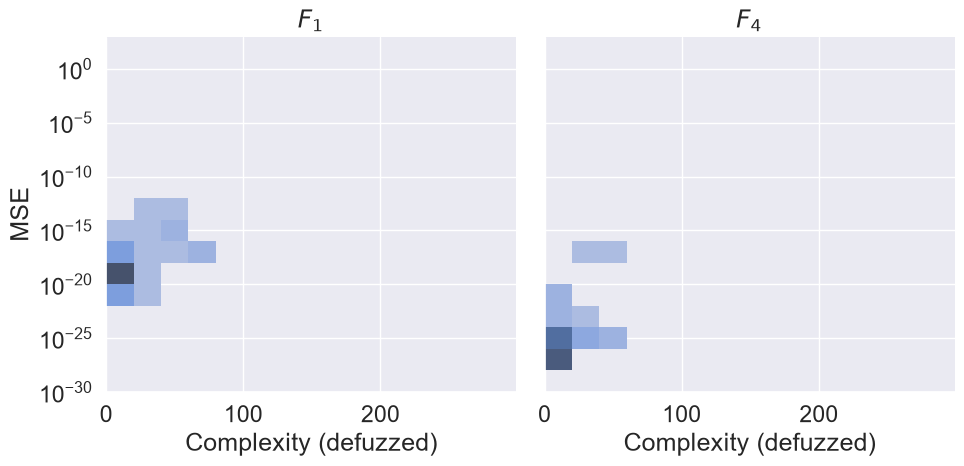

In [29]:
au.complexity_mse_displot(
    srb.loc[data_sets_polynomial],
    file_stem="srb-polynomial-complexit-mse-displot",
    **polynomial_plot_params
)

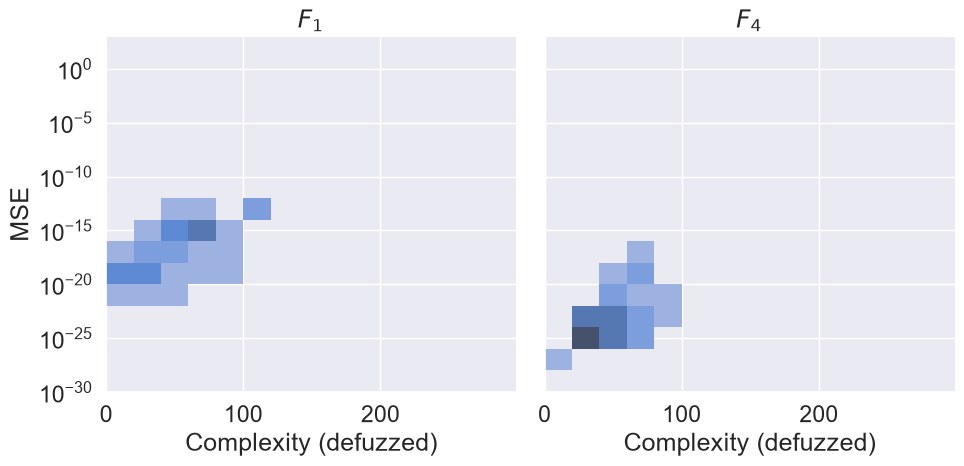

In [30]:
au.complexity_mse_displot(
    cht.loc[data_sets_polynomial],
    file_stem="cht-polynomial-complexity-mse-displot",
    **polynomial_plot_params
)

## Rational functions

In [31]:
data_sets_rational = ["F7"]

In [32]:
srb.loc[srb_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
F7,24,2.486402e-26,13,0.230000000000037 + (4.73333333333333*x1 + 4.7...


In [33]:
cht.loc[cht_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
F7,19,2.349767e-26,13,0.230000000000016 + (4.73333333333333*x1 + 4.7...


In [34]:
au.count_by_threshold(srb.loc[data_sets_rational])

data_set
F7    30
Name: mse, dtype: int64

In [35]:
au.count_by_threshold(cht.loc[data_sets_rational])

data_set
F7    32
Name: mse, dtype: int64

In [36]:
srb.loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

mse  complexity_defuzz  \
data_set sample_num                                    
F7       24          2.486402e-26                 13   
         32          2.510835e-26                 14   
         20          2.520819e-26                 14   
         31          2.593846e-26                 13   
         22          2.656220e-26                 21   
         30          2.669638e-26                 13   
         8           2.670149e-26                 13   
         1           3.010205e-26                 13   
         9           3.175917e-26                 13   
         18          3.222494e-26                 13   
         25          4.103972e-26                 13   
         27          4.606972e-26                 14   
         7           4.833526e-26                 13   
         28          5.326147e-26                 13   
         2           5.895817e-26                 16   
         21          6.173595e-26                 13   
         19          6.258290e-26                 14   
         13          8.724985e-26                 22   
         26          1.156946e-25                 13   
         3           1.244401e-25                 22   
         15          1.465260e-25                 26   
         4           1.478199e-25                 13   
         16          1.547870e-25                 10   
         14          1.679889e-25                 13   
         12          4.553782e-25                 13   
         29          1.129432e-24                 30   
         23          1.176721e-24                 14   
         10          1.755346e-24                 40   
         17          4.098912e-24                 13   
         6           4.438640e-21                 21   
         5           3.165184e-19                 22   
         11          8.816232e-14                 13   

                                                          sympy_defuzz  
data_set sample_num                                                     
F7       24          0.230000000000037 + (4.73333333333333*x1 + 4.7...  
         32          4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
         20          4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
         31          0.230000000000061 + (4.73333333333333*x1 + 4.7...  
         22          0.229999999999989 + (1.9869223393383*x1 + 1.98...  
         30          0.230000000000076 + (4.73333333333333*x1 + 4.7...  
         8           0.23000000000007 + (4.73333333333333*x1 + 4.73...  
         1           0.229999999999942 + (4.73333333333333*x1 + 4.7...  
         9           0.230000000000105 + (4.73333333333333*x1 + 4.7...  
         18          0.229999999999932 + (4.73333333333333*x1 + 4.7...  
         25          0.230000000000163 + (4.73333333333333*x1 + 4.7...  
         27          4.73333333333331*x1/x3 + 4.73333333333334*x2/x...  
         7           0.230000000000023 + (4.73333333333333*x1 + 4.7...  
         28          0.229999999999995 + (4.73333333333333*x1 + 4.7...  
         2           -2.13666666666651 + (4.73333333333333*x1 + 4.7...  
         21          0.230000000000148 + (4.73333333333333*x1 + 4.7...  
         19          4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
         13          0.230000000000038 + (0.237878118113327*x1 + 0....  
         26          0.230000000000245 + (4.73333333333333*x1 + 4.7...  
         3           0.229999999999934 + (1.57777777777778*x1 + 1.5...  
         15          2.3666666666667*x1/x3 + 2.36666666666664*x2/x3...  
         4           0.230000000000037 + (4.73333333333333*x1 + 4.7...  
         16          0.230000000000532 + (4.73333333333333*x1 + 4.7...  
         14          0.23000000000008 + (4.7333333333334*x1 + 4.733...  
         12          0.230000000000457 + (4.73333333333333*x1 + 4.7...  
         29          4.14661546071241*x1/x3 + 3.55989758809149*x2/x...  
         23          4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
        

In [37]:
srb.loc["F7"].sympy_defuzz.apply(
    lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-10))

sample_num
24    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
32    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
20    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
31    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
22    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
30    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
8     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
1     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
9     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
18    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
25    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
27    4.73333333333331*x1/x3 + 4.73333333333334*x2/x...
7     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
28    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
2     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
21    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
19    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
13    4.73333333333333*x1/x3 + 4.7333

In [38]:
cht.loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

mse  complexity_defuzz  \
data_set sample_num                                    
F7       19          2.349767e-26                 13   
         12          2.418203e-26                 13   
         2           2.490957e-26                 13   
         14          2.515559e-26                 13   
         25          2.548008e-26                 14   
         26          2.577184e-26                 13   
         22          3.010731e-26                 14   
         17          3.128616e-26                 13   
         16          3.178091e-26                 13   
         9           4.679895e-26                 14   
         15          5.797763e-26                 21   
         24          9.117545e-26                 14   
         29          9.182716e-26                 14   
         32          9.568485e-26                 14   
         30          1.021741e-25                 22   
         10          1.040374e-25                 13   
         1           1.091163e-25                 13   
         13          1.145110e-25                 14   
         28          1.461766e-25                 13   
         31          2.052225e-25                 13   
         8           2.751545e-25                 22   
         20          3.277249e-25                 13   
         23          4.198194e-25                 14   
         7           4.200985e-25                 13   
         18          1.154107e-24                 13   
         21          1.395219e-24                 10   
         4           4.318504e-24                 14   
         11          1.547959e-23                 13   
         6           2.313282e-23                 13   
         3           9.545347e-23                 13   
         5           2.163589e-22                 25   
         27          6.155320e-21                 14   

                                                          sympy_defuzz  
data_set sample_num                                                     
F7       19          0.230000000000016 + (4.73333333333333*x1 + 4.7...  
         12          0.229999999999997 + (4.73333333333333*x1 + 4.7...  
         2           0.230000000000034 + (4.73333333333333*x1 + 4.7...  
         14          0.229999999999975 + (4.73333333333333*x1 + 4.7...  
         25          4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
         26          0.229999999999977 + (4.73333333333333*x1 + 4.7...  
         22          4.73333333333332*x1/x3 + 4.73333333333333*x2/x...  
         17          0.229999999999899 + (4.73333333333333*x1 + 4.7...  
         16          0.229999999999856 + (4.73333333333333*x1 + 4.7...  
         9           4.73333333333333*x1/x3 + 4.73333333333333*x2/x...  
         15          0.230000000000047 + (0.964092663966598*x1 + 0....  
         24          0.229999999999995 + (4.73333333333334*x1 + 4.7...  
         29          0.230000000000033 + (4.73333333333334*x1 + 4.7...  
         32          4.73333333333334*x1/x3 + 4.73333333333334*x2/x...  
         30          0.230000000000108 + (1.57777777777778*x1 + 1.5...  
         10          0.230000000000099 + (4.73333333333333*x1 + 4.7...  
         1           0.229999999999874 + (4.73333333333334*x1 + 4.7...  
         13          0.230000000000188 + (4.73333333333334*x1 + 4.7...  
         28          0.229999999999538 + (4.73333333333333*x1 + 4.7...  
         31          0.230000000000721 + (4.73333333333333*x1 + 4.7...  
         8           0.229999999999915 + (1.57777777777778*x1 + 1.5...  
         20          0.229999999999084 + (4.73333333333333*x1 + 4.7...  
         23          0.229999999999501 - (-4.73333333333333*x1 - 4....  
         7           0.230000000000006 + (4.73333333333333*x1 + 4.7...  
         18          0.230000000000046 + (4.73333333333282*x1 + 4.7...  
         21          0.230000000002219 + (4.73333333333333*x1 + 4.7...  
         4           0.230000000004165 + (4.7333333333335*x1 + 4.73...  
        

In [39]:
cht.loc["F7"].sympy_defuzz.apply(
    lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-4))

sample_num
19    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
12    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
2     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
14    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
25    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
26    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
22    4.73333333333332*x1/x3 + 4.73333333333333*x2/x...
17    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
16    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
9     4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
15    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
24    4.73333333333334*x1/x3 + 4.73333333333334*x2/x...
29    4.73333333333334*x1/x3 + 4.73333333333334*x2/x...
32    4.73333333333334*x1/x3 + 4.73333333333334*x2/x...
30    4.73333333333334*x1/x3 + 4.73333333333334*x2/x...
10    4.73333333333333*x1/x3 + 4.73333333333333*x2/x...
1     4.73333333333334*x1/x3 + 4.73333333333334*x2/x...
13    4.73333333333334*x1/x3 + 4.7333

In [40]:
rational_plot_params = {
    "spiffy_titles": ["$F_7$"],
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 149),
    "mse_lims": (1e-30, 1e7),
    "complexity_binwidth": 10,
    "mse_binwidth": 2.0,
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

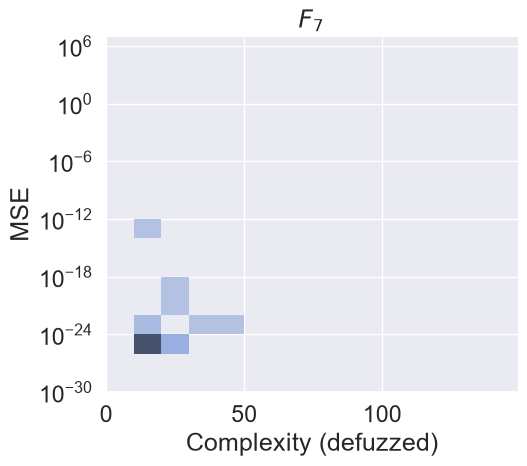

In [41]:
au.complexity_mse_displot(
    srb.loc[data_sets_rational],
    file_stem="srb-rational-complexity-mse-displot",
    **rational_plot_params
)

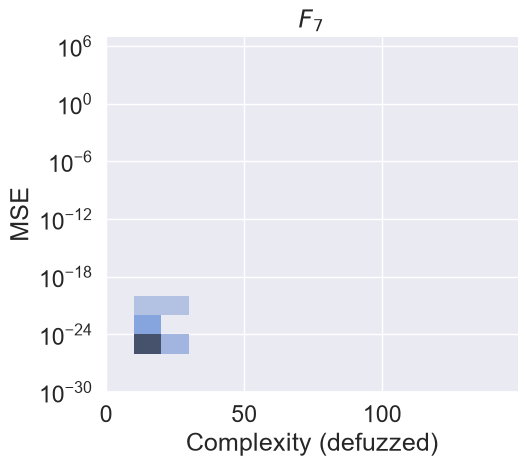

In [42]:
au.complexity_mse_displot(
    cht.loc[data_sets_rational],
    file_stem="cht-rational-complexity-mse-displot",
    **rational_plot_params
)

## Medium: $F_5$

In [43]:
data_sets_medium = ["F5"]

In [44]:
srb.loc["F5"]

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
16,8.027778e-12,1.321405e-28,10,9,1.5000000000000002*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2),1.5000000000000002*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2),1.5000000000000002*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2)
28,7.027778e-12,1.434488e-28,9,9,1.5000000000000004*exp(x1) + 5.000000000000007...,1.5*exp(x1) + 5*cos(x2),1.5000000000000004*exp(x1) + 5.000000000000007...,1.5*exp(x1) + 5*cos(x2),1.5000000000000004*exp(x1) + 5.000000000000007...,1.5*exp(x1) + 5*cos(x2)
10,9.812881e-12,1.438999e-28,10,9,1.5000000000000004*exp(x1) + 5.000000000000009...,1.5*exp(x1) + 5*cos(x2),1.5000000000000004*exp(x1) + 5.000000000000009...,1.5*exp(x1) + 5*cos(x2),1.5000000000000004*exp(x1) + 5.000000000000009...,1.5*exp(x1) + 5*cos(x2)
30,1.034764e-11,1.464969e-28,10,9,1.5000000000000002*exp(x1) + 4.999999999999986...,1.5*exp(x1) + 5*cos(x2),1.5000000000000002*exp(x1) + 4.999999999999986...,1.5*exp(x1) + 5*cos(x2),1.5000000000000002*exp(x1) + 4.999999999999986...,1.5*exp(x1) + 5*cos(x2)
26,1.217994e-11,1.764337e-28,10,9,1.4999999999999993*exp(x1) + 5.000000000000004...,1.5*exp(x1) + 5*cos(x2),1.4999999999999993*exp(x1) + 5.000000000000004...,1.5*exp(x1) + 5*cos(x2),1.4999999999999993*exp(x1) + 5.000000000000004...,1.5*exp(x1) + 5*cos(x2)
14,7.250000e-12,2.273629e-28,10,9,1.4999999999999996*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2),1.4999999999999996*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2),1.4999999999999996*exp(x1) + 4.999999999999998...,1.5*exp(x1) + 5*cos(x2)
21,1.002778e-11,2.321588e-28,10,9,1.4999999999999998*exp(x1) + 5.000000000000002...,1.5*exp(x1) + 5*cos(x2),1.4999999999999998*exp(x1) + 5.000000000000002...,1.5*exp(x1) + 5*cos(x2),1.4999999999999998*exp(x1) + 5.000000000000002...,1.5*exp(x1) + 5*cos(x2)
15,1.175076e-11,2.329976e-28,10,9,1.5000000000000007*exp(x1) + 5.000000000000005...,1.5*exp(x1) + 5*cos(x2),1.5000000000000007*exp(x1) + 5.000000000000005...,1.5*exp(x1) + 5*cos(x2),1.5000000000000007*exp(x1) + 5.000000000000005...,1.5*exp(x1) + 5*cos(x2)
13,9.028377e-12,2.446379e-28,10,9,1.4999999999999996*exp(x1) + 4.999999999999992...,1.5*exp(x1) + 5*cos(x2),1.4999999999999996*exp(x1) + 4.999999999999992...,1.5*exp(x1) + 5*cos(x2),1.4999999999999996*exp(x1) + 4.999999999999992...,1.5*exp(x1) + 5*cos(x2)


In [45]:
srb.loc["F5"].sympy.apply(
    lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-10))

sample_num
16    1.5000000000000002*exp(x1) + 5*cos(x2)
28    1.5000000000000004*exp(x1) + 5*cos(x2)
10    1.5000000000000004*exp(x1) + 5*cos(x2)
30    1.5000000000000002*exp(x1) + 5*cos(x2)
26    1.4999999999999993*exp(x1) + 5*cos(x2)
14    1.4999999999999996*exp(x1) + 5*cos(x2)
21    1.4999999999999998*exp(x1) + 5*cos(x2)
15    1.5000000000000007*exp(x1) + 5*cos(x2)
13    1.4999999999999996*exp(x1) + 5*cos(x2)
3     1.4999999999999996*exp(x1) + 5*cos(x2)
22    1.5000000000000009*exp(x1) + 5*cos(x2)
18    1.5000000000000008*exp(x1) + 5*cos(x2)
24    1.5000000000000007*exp(x1) + 5*cos(x2)
5     1.4999999999999998*exp(x1) + 5*cos(x2)
2                    1.5*exp(x1) + 5*cos(x2)
27    1.4999999999999991*exp(x1) + 5*cos(x2)
31    1.5000000000000007*exp(x1) + 5*cos(x2)
25     1.499999999999999*exp(x1) + 5*cos(x2)
11    1.5000000000000009*exp(x1) + 5*cos(x2)
7      1.499999999999999*exp(x1) + 5*cos(x2)
20    1.4999999999999982*exp(x1) + 5*cos(x2)
6                    1.5*exp(x1) + 5*cos(x2)

My usual cheats don't help here, because I use a larger exponential and trig inventory, which leads to a lot of distraction and cruft that really damages the solutions.

In [46]:
cht.loc["F5"]

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
6,4.733701e-09,4.842086e-09,109,107,-2.5996038422126872*x2**2 - 1.7823844479357248...,-2.59960384221269*x2**2 - 1.78238444793572*x2 ...,-2.5996038422126872*x2**2 - 1.7823844479357248...,-2.59960384221269*x2**2 - 1.78238444793572*x2 ...,-2.5996038422126872*x2**2 - 1.7823844479357248...,-2.59960384221269*x2**2 - 1.78238444793572*x2 ...
21,8.270104e-09,7.845714e-09,119,78,9.8397631348354233*x2 + 0.0001870116386607241*...,9.83976313483542*x2 + 0.000187011638660724*(x2...,9.8397631348354233*x2 + 0.0001870116386607241*...,9.83976313483542*x2 + 0.000187011638660724*(x2...,9.8397631348354233*x2 - (3.2662479187350896e-9...,9.83976313483542*x2 + 0.000187011638660724*(x2...
30,2.718773e-08,1.196910e-08,62,62,-1.863131411175498*x2 - 3.196396087644991*(x2 ...,-1.8631314111755*x2 - 3.19639608764499*(x2 + 1...,-1.863131411175498*x2 - 3.196396087644991*(x2 ...,-1.8631314111755*x2 - 3.19639608764499*(x2 + 1...,-1.863131411175498*x2 - 3.196396087644991*(x2 ...,-1.8631314111755*x2 - 3.19639608764499*(x2 + 1...
20,2.765842e-08,1.592567e-08,74,74,1.814454949045086e-5*x1 + 2.0206271634112841*x...,1.81445494904509e-5*x1 + 2.02062716341128*x2**...,1.814454949045086e-5*x1 + 2.0206271634112841*x...,1.81445494904509e-5*x1 + 2.02062716341128*x2**...,1.814454949045086e-5*x1 + 2.0206271634112841*x...,1.81445494904509e-5*x1 + 2.02062716341128*x2**...
17,1.796622e-08,1.600001e-08,40,40,-2.4905276439850869*x2 - 0.0134931391745485*(2...,-2.49052764398509*x2 - 0.0134931391745485*(2.6...,-2.4905276439850869*x2 - 0.0134931391745485*(2...,-2.49052764398509*x2 - 0.0134931391745485*(2.6...,-2.4905276439850869*x2 - 0.0134931391745485*(2...,-2.49052764398509*x2 - 0.0134931391745485*(2.6...
16,1.666252e-08,1.668346e-08,183,171,7.170992349900451*x2 + 4.516942050981934*x2/(2...,7.17099234990045*x2 + 4.51694205098193*x2/(21....,7.170992349900451*x2 + 4.516942050981934*x2/(2...,7.17099234990045*x2 + 4.51694205098193*x2/(21....,7.170992349900451*x2 + 4.516942050981934*x2/(2...,7.17099234990045*x2 + 4.51694205098193*x2/(21....
32,1.068111e-07,1.977768e-08,47,47,0.2786667752921907*x2**2 + 0.06411700074355872...,0.278666775292191*x2**2 + 0.0641170007435587*x...,0.2786667752921907*x2**2 + 0.06411700074355872...,0.278666775292191*x2**2 + 0.0641170007435587*x...,0.2786667752921907*x2**2 + 0.06411700074355872...,0.278666775292191*x2**2 + 0.0641170007435587*x...
13,2.435542e-08,2.304122e-08,83,67,7.704350786914441*x2 + 1.500000225386347*exp(x...,7.70435078691444*x2 + 1.50000022538635*exp(x1)...,7.704350786914441*x2 + 1.500000225386347*exp(x...,7.70435078691444*x2 + 1.50000022538635*exp(x1)...,7.704350786914441*x2 + 1.500000225386347*exp(x...,7.70435078691444*x2 + 1.50000022538635*exp(x1)...
23,3.329898e-08,3.037879e-08,88,88,2.82283616757696e-5*x1 + 5.0201807105012759*x2...,2.82283616757696e-5*x1 + 5.02018071050128*x2 -...,2.82283616757696e-5*x1 + 5.0201807105012759*x2...,2.82283616757696e-5*x1 + 5.02018071050128*x2 -...,2.82283616757696e-5*x1 + 5.0201807105012759*x2...,2.82283616757696e-5*x1 + 5.02018071050128*x2 -...


In [47]:
cht.loc["F5"].sympy_defuzz.apply(
    lambda e: au.replace_near_integer(sympy.expand(e), tolerance=1.0e-4))

sample_num
6     -0.00343503429195364*x2**6 - 0.006630618364137...
21    0.257929145364565*x2**4 + 0.652166142205399*x2...
30    -0.000951622903881933*x2**7 - 0.00586027748110...
20    -0.0444637614660939*x2**4 + 0.292341197721354*...
17    -0.053972556698194*x2**4 + 0.171172692286583*x...
16    7.17099234990045*x2 - 8.26309320251375*x2/(1 +...
32    0.278666775292191*x2**2 + 0.0641170007435587*x...
13    7.70435078691444*x2 + 1.50000022538635*exp(x1)...
23    0.356052533348008*x2**4 + 0.468277823078353*x2...
8     -0.22264959065289*x2**2*exp(0.0019577295510586...
18    0.000165482565886811*x2**7 - 0.005077722141618...
12    -0.000182482617488243*x1 + 0.00047301639242730...
25    11.607626795068*x2 - 20.4468409939699/(1 + 2.0...
10    0.211104494968213*x2**4 + 0.276601490809994*x2...
9     0.000442088148233572*x2**6 + 0.002537096867005...
4     -0.0610431206186513*x2**4 + 0.769917225711995*...
5     0.137158905840159*x2**2 + 9.62679787663136*x2 ...
29    -0.0595401736395117*x2**5 + 0.4

In [48]:
medium_plot_params = {
    "spiffy_titles": ["$F_5$"],
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 79),
    "mse_lims": (1e-30, 1e1),
    "complexity_binwidth": 5,
    "mse_binwidth": 2.0,
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

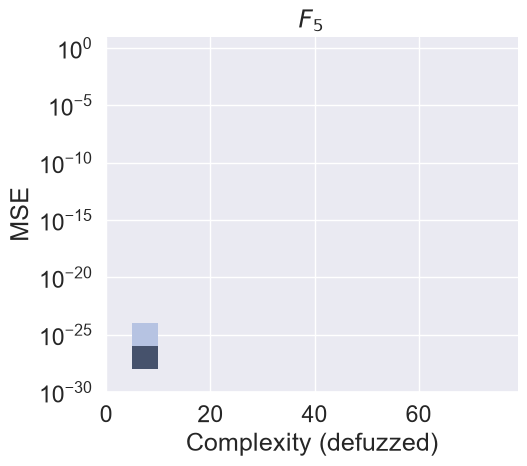

In [49]:
au.complexity_mse_displot(
    srb.loc[data_sets_medium],
    file_stem="srb-medium-complexity-mse-displot",
    **medium_plot_params
)

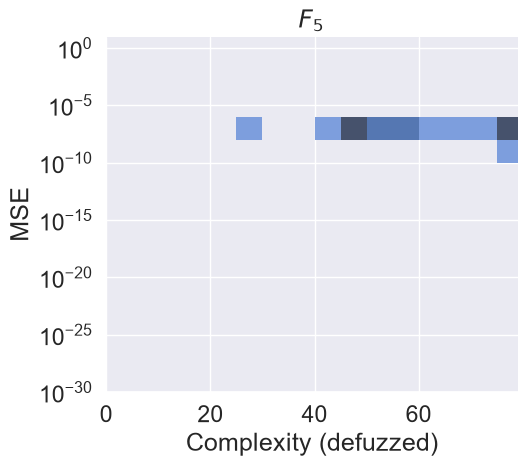

In [50]:
au.complexity_mse_displot(
    cht.loc[data_sets_medium],
    file_stem="cht-medium-complexity-mse-displot",
    **medium_plot_params
)

## Medium: $F_8$

In [51]:
srb.loc["F8"].sympy.apply(
    lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=1.0e-10))

sample_num
4     29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
28    29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
10    29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
15    29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
16    29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
24    29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
32    29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
27    29.5775252514472*(x1*x2*x3)**0.5 + 6.779999999...
23    29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
21    29.5775252514471*(x1*x2*x3)**0.5 + 6.779999999...
25    29.5775252514471*(x1*x2*x3)**0.5 + 6.779999999...
31    29.5775252514472*(x1*x2*x3)**0.5 + 6.779999999...
9     29.5775252514469*(x1*x2*x3)**0.5 + 6.780000000...
5     29.5775252514471*(x1*x2*x3)**0.5 + 6.779999999...
8     29.5775252514477*(x1*x2*x3)**0.5 + 6.779999999...
1     29.5775252514472*(x1*x2*x3)**0.5 + 6.779999999...
17    29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
29    29.5775252514471*(x1*x2*x3)**0.

## Hard: $F_2$

None of these are any good.

In [52]:
srb.loc["F2"]

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
26,0.041773,0.044953,182,143,0.001310100747842376*x1 + 0.004596488837572806...,0.00131010074784238*x1 + 0.00459648883757281*(...,0.001310100747842376*feature + 0.0045964888375...,0.00131010074784238*feature + 0.00459648883757...,0.001310100747842376*feature + (0.009192977675...,0.00131010074784238*feature + (0.0091929776751...
20,0.223192,0.220359,90,90,5.7520306002301336e-5*x1**4 + 0.00646561434108...,5.75203060023013e-5*x1**4 + 0.0064656143410886...,5.7520306002301336e-5*feature**4 + 0.006465614...,5.75203060023013e-5*feature**4 + 0.00646561434...,5.7520306002301336e-5*feature**4 + 0.006465614...,5.75203060023013e-5*feature**4 + 0.00646561434...
7,0.226745,0.229052,108,108,-0.057862715482687672*x1**2 + 0.09382222088014...,-0.0578627154826877*x1**2 + 0.0938222208801458...,-0.057862715482687672*feature**2 + 0.093822220...,-0.0578627154826877*feature**2 + 0.09382222088...,-0.057862715482687672*feature**2 + 0.093822220...,-0.0578627154826877*feature**2 + 0.09382222088...
17,0.218753,0.245876,51,45,-0.0009796371744639101*x1 - 4.507850814879553*...,-0.00097963717446391*x1 - 4.50785081487955*sin...,-0.0009796371744639101*feature - 4.50785081487...,-0.00097963717446391*feature - 4.5078508148795...,-0.0009796371744639101*feature - 4.50785081487...,-0.00097963717446391*feature - 4.5078508148795...
18,0.247659,0.248331,40,40,-0.0024048325490335308*x1**2 - 0.0039492336221...,-0.00240483254903353*x1**2 - 0.003949233622162...,-0.0024048325490335308*feature**2 - 0.00394923...,-0.00240483254903353*feature**2 - 0.0039492336...,-0.0024048325490335308*feature**2 - 0.00394923...,-0.00240483254903353*feature**2 - 0.0039492336...
16,0.246638,0.250427,52,46,-0.00022659367646930362*x1*(x1*(x1 - 0.9163064...,-0.000226593676469304*x1*(x1*(x1 - 0.916306479...,-0.00022659367646930362*feature*(feature*(feat...,-0.000226593676469304*feature*(feature*(featur...,-0.00022659367646930362*feature*(feature*(feat...,-0.000226593676469304*feature*(feature*(featur...
4,0.225498,0.256126,76,76,-0.007758410625755136*x1 - 0.29134468219023*(s...,-0.00775841062575514*x1 - 0.29134468219023*(si...,-0.007758410625755136*feature - 0.291344682190...,-0.00775841062575514*feature - 0.2913446821902...,-0.007758410625755136*feature - 0.291344682190...,-0.00775841062575514*feature - 0.2913446821902...
21,0.240987,0.260978,49,40,-0.0086377744763325608*x1 - 1.804489263487256e...,-0.00863777447633256*x1 - 0.0713103649915988*(...,-0.0086377744763325608*feature - 1.80448926348...,-0.00863777447633256*feature - 0.0713103649915...,-0.0086377744763325608*feature - 1.80448926348...,-0.00863777447633256*feature - 0.0713103649915...
14,0.273611,0.263481,55,31,0.002113231890502824*x1 + 79.70120341571462*si...,0.00211323189050282*x1 - 0.021183021453559*cos...,0.002113231890502824*feature + 79.701203415714...,0.00211323189050282*feature - 0.02118302145355...,0.002113231890502824*feature + 79.701203415714...,0.00211323189050282*feature - 0.02118302145355...


In [53]:
cht.loc["F2"]

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
19,0.000006,0.000004,87,56,-1.4368547942960413e-18*x1**6*(0.0382889676991...,-410.74754998442*x1**2 - 15.7270870360052*x1 +...,-1.4368547942960413e-18*feature**6*(0.03828896...,-410.74754998442*feature**2 - 15.7270870360052...,-1.4368547942960413e-18*feature**6*(0.03828896...,-410.74754998442*feature**2 - 15.7270870360052...
21,0.166934,0.165885,59,59,-0.01934117724848362*x1**2 + 4.596025469199517...,-0.0193411772484836*x1**2 + 4.59602546919952*(...,-0.01934117724848362*feature**2 + 4.5960254691...,-0.0193411772484836*feature**2 + 4.59602546919...,-0.01934117724848362*feature**2 + 4.5960254691...,-0.0193411772484836*feature**2 + 4.59602546919...
29,0.195428,0.210589,99,99,0.039994432999002523*x1 - 0.017215874688889416...,0.0399944329990025*x1 - 0.0172158746888894*(0....,0.039994432999002523*feature - 0.0172158746888...,0.0399944329990025*feature - 0.017215874688889...,0.039994432999002523*feature - (0.016230222376...,0.0399944329990025*feature - (0.01623022237633...
28,0.241392,0.245198,41,41,1.1039042139159632*x1**2 + 0.23213453728015315...,1.10390421391596*x1**2 + 0.232134537280153*x1 ...,1.1039042139159632*feature**2 + 0.232134537280...,1.10390421391596*feature**2 + 0.23213453728015...,1.1039042139159632*feature**2 + 0.232134537280...,1.10390421391596*feature**2 + 0.23213453728015...
31,0.273894,0.290362,82,44,477.77306310831077*x1**2 - 54.304210583278559*...,477.773063108311*x1**2 - 54.3042105832786*x1 -...,477.77306310831077*feature**2 - 54.30421058327...,477.773063108311*feature**2 - 54.3042105832786...,477.77306310831077*feature**2 - 54.30421058327...,477.773063108311*feature**2 - 54.3042105832786...
22,0.291902,0.295777,118,113,-1.9391477631858884e-6*x1**3 - 0.0308827062409...,-0.0308827062409378*x1 + 3.14532873687827*(0.0...,-1.9391477631858884e-6*feature**3 - 0.03088270...,-0.0308827062409378*feature + 3.14532873687827...,-1.9391477631858884e-6*feature**3 - 0.03088270...,-0.0308827062409378*feature + (0.0001204779671...
14,0.315144,0.314665,47,47,-0.0003101717869719739*x1*(3*x1 - 0.2646101742...,-0.000310171786971974*x1*(3*x1 - 0.26461017429...,-0.0003101717869719739*feature*(3*feature - 0....,-0.000310171786971974*feature*(3*feature - 0.2...,-0.0003101717869719739*feature*(3*feature - 0....,-0.000310171786971974*feature*(3*feature - 0.2...
5,0.311455,0.314941,89,89,0.008547675064171225*x1 + 0.13285714627193673*...,0.00854767506417122*x1 + 0.132857146271937*(1....,0.008547675064171225*feature + 0.1328571462719...,0.00854767506417122*feature + 0.13285714627193...,0.008547675064171225*feature + (0.000888315371...,0.00854767506417122*feature + (0.0008883153714...
16,0.340574,0.323584,84,84,-0.15549993865013679*x1 + 0.000316711326119560...,-0.155499938650137*x1 + 0.00031671132611956*(1...,-0.15549993865013679*feature + 0.0003167113261...,-0.155499938650137*feature + 0.000316711326119...,-0.15549993865013679*feature + (0.000561218990...,-0.155499938650137*feature + (0.00056121899025...


## Hard: $F_8$

A bunch of these are correct

In [54]:
srb.loc["F8", ["mse", "complexity_defuzz", "sympy_defuzz"]]

,mse,complexity_defuzz,sympy_defuzz
sample_num,,,
4,1.592582e-26,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
28,1.394993e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
10,1.472871e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
15,2.031715e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
16,2.145956e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
24,2.221908e-25,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
32,2.927263e-25,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.780000000...
27,4.041589e-25,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.779999999...
23,4.153647e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...


In [55]:
cht.loc["F8", ["mse", "complexity_defuzz", "sympy_defuzz"]]

,mse,complexity_defuzz,sympy_defuzz
sample_num,,,
29,8.347441e-26,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
7,8.820177e-26,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
24,9.951355e-26,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
25,2.115730e-25,10,29.5775252514471*(x1*x2*x3)**0.5 + 6.780000000...
6,2.363525e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.779999999...
10,2.560654e-25,10,29.5775252514472*(x1*x2*x3)**0.5 + 6.779999999...
13,5.109925e-25,10,29.5775252514473*(x1*x2*x3)**0.5 + 6.780000000...
5,5.585152e-25,10,29.577525251447*(x1*x2*x3)**0.5 + 6.7800000000...
18,8.921242e-25,10,29.5775252514471*(x1*x2*x3)**0.5 + 6.780000000...


In [56]:
f8_plot_params = {
    "spiffy_titles": ["$F_8$"],
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 139),
    "mse_lims": (1e-30, 1e7),
    "complexity_binwidth": 10,
    "mse_binwidth": 2.0,
    "xlabel": "Complexity (defuzzed)",
    "ylabel": "MSE",
}

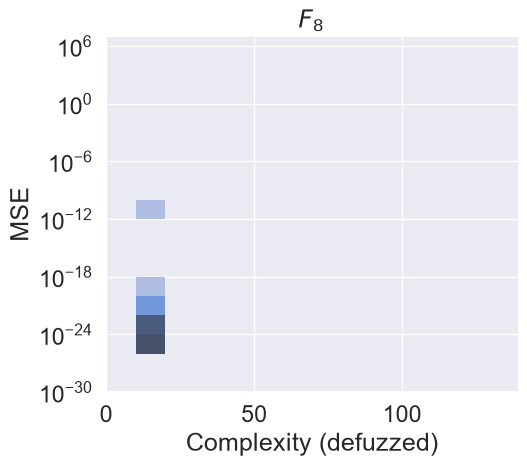

In [57]:
au.complexity_mse_displot(
    srb.loc[["F8"]],
    file_stem="srb-f8-complexity-mse-displot",
    **f8_plot_params
)

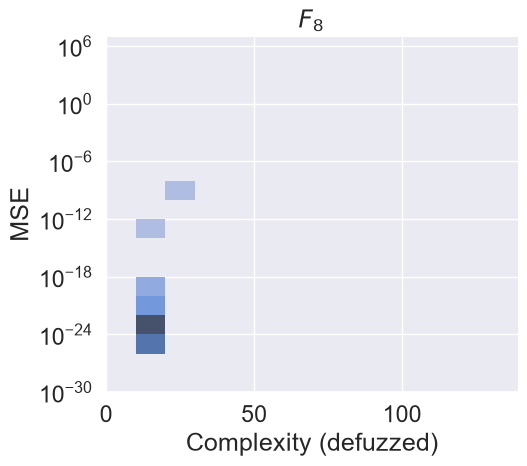

In [58]:
au.complexity_mse_displot(
    cht.loc[["F8"]],
    file_stem="cht-f8-complexity-mse-displot",
    **f8_plot_params
)